In [68]:
import time
import pandas as pd
import json
import numpy as np
from datetime import datetime
from datetime import timezone
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import ListedColormap
import numpy as np
# import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [69]:
def remove_specific_cycles(data_loader, indices_to_remove):
    """
    Excludes specific indices from every key in the dataset.
    indices_to_remove: list of integers (e.g., [1, 3, 6])
    """
    cleaned_data = {}
    
    for key in data_loader.files:
        original_list = list(data_loader[key])
        # Keep only the items whose index is NOT in our 'remove' list
        cleaned_data[key] = [
            cycle for i, cycle in enumerate(original_list) 
            if i not in indices_to_remove
        ]
        
    return cleaned_data

def get_cycle_stats(data_source, param_prefix, leg, norm_points=100):
    """
    Interpolates cycles for a specific leg/parameter and calculates mean/std.
    """
    key = f'{param_prefix}_{leg}'
    if key not in data_source:
        return None, None, None

    raw_cycles = data_source[key]
    normalized_list = []
    

    for j, cycle in enumerate(raw_cycles):
            
        x_old = np.linspace(0, 100, len(cycle))
        x_new = np.linspace(0, 100, norm_points)
        norm_cycle = np.interp(x_new, x_old, cycle)
        normalized_list.append(norm_cycle)
    
    if not normalized_list:
        return None, None, None

    norm_matrix = np.array(normalized_list)
    mean_vals = np.mean(norm_matrix, axis=0)
    std_vals = np.std(norm_matrix, axis=0)
    x_axis = np.linspace(0, 100, norm_points)

    return x_axis, mean_vals, std_vals

In [70]:
def load_cycles_from_npz(filename):
    """
    Loads a flattened .npz file and reconstructs the nested dictionary.
    """
    data = np.load(filename)
    reconstructed = {}
    
    for key in data.files:
        # Split the key (e.g., 'rough_foot_force')
        # We use rsplit once from the right to handle sensor names with underscores
        parts = key.split('_', 1) 
        if len(parts) < 2: continue
        
        terrain, sensor = parts[0], parts[1]
        
        if terrain not in reconstructed:
            reconstructed[terrain] = {}
        
        # Convert the (N, 100, F) array back into a list of (100, F) arrays
        # This makes it compatible with your existing segment_all_trials output
        reconstructed[terrain][sensor] = [cycle for cycle in data[key]]
        
    print(f"Loaded {len(reconstructed)} terrains from {filename}")
    return reconstructed

# --- Execution ---
dataset = load_cycles_from_npz('walking_terrain_datasets.npz')

Loaded 3 terrains from walking_terrain_datasets.npz


In [71]:
name_joints = ['FR_J1', 'FR_J2', 'FR_J3', 'FR_J4', 
 'BR_J1', 'BR_J2', 'BR_J3', 'BR_J4', 
 'FL_J1', 'FL_J2', 'FL_J3', 'FL_J4', 
 'BL_J1', 'BL_J2', 'BL_J3', 'BL_J4']

name_legs = ['FR', 'BR', 'FL', 'BL']

# Plot show

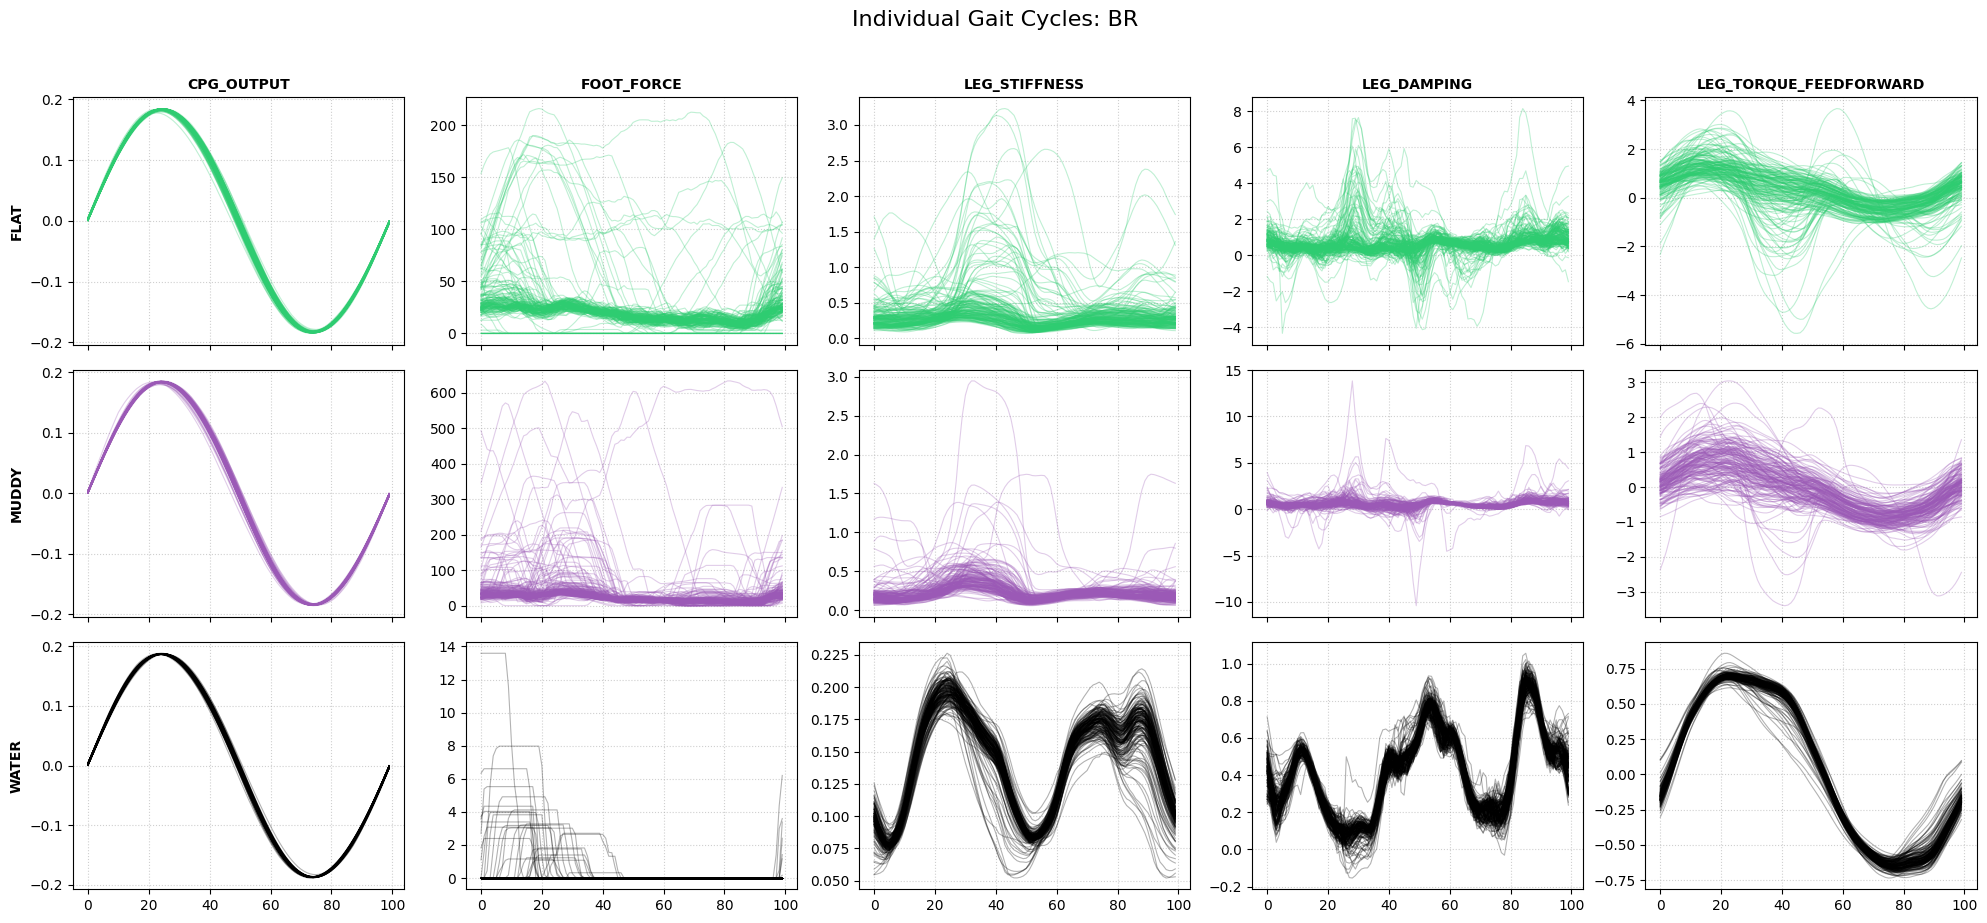

In [72]:
def plot_all_individual_cycles(cycle_results, sensor_list, feature_idx=0):
    """
    Plots every single cycle for every terrain to see the raw distribution.
    """
    terrains = list(cycle_results.keys())
    num_terrains = len(terrains)
    num_sensors = len(sensor_list)
    
    colors = {
        'flat': '#2ecc71', 'rough': '#e74c3c', 'sponge': '#3498db', 
        'sandy': '#f1c40f', 'muddy': '#9b59b6'
    }

    # Use a dynamic title based on the index
    # We try to find the name from the global scope, otherwise use the index number
    try:
        # Check if the first sensor in the list is a leg or joint sensor
        is_joint = 'joint' in sensor_list[0]
        feature_name = name_joints[feature_idx] if is_joint else name_legs[feature_idx]
    except (NameError, IndexError):
        feature_name = f"Index {feature_idx}"

    fig, axes = plt.subplots(num_terrains, num_sensors, 
                               figsize=(4 * num_sensors, 3 * num_terrains), 
                               sharex=True, squeeze=False) # squeeze=False keeps axes 2D (rows, cols)

    for t_idx, terrain in enumerate(terrains):
        for s_idx, sensor in enumerate(sensor_list):
            ax = axes[t_idx, s_idx]
            
            # Use .get() to avoid KeyError if a sensor is missing for a terrain
            cycles = cycle_results.get(terrain, {}).get(sensor, [])
            
            if not cycles or len(cycles) == 0:
                ax.text(0.5, 0.5, 'No Data', ha='center', transform=ax.transAxes)
                continue
            
            color = colors.get(terrain, 'black')
            
            # Plot every single cycle
            for cycle in cycles:
                # cycle shape is (100, num_features)
                ax.plot(cycle[:, feature_idx], color=color, alpha=0.3, linewidth=0.8)
            
            # Formatting titles only for the top row
            if t_idx == 0:
                ax.set_title(f"{sensor.upper()}", fontsize=10, fontweight='bold')
            
            # Formatting labels only for the first column
            if s_idx == 0:
                ax.set_ylabel(f"{terrain.upper()}", fontsize=10, fontweight='bold')
            
            ax.grid(True, linestyle=':', alpha=0.6)

    plt.suptitle(f"Individual Gait Cycles: {feature_name}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# --- Execution ---
sensors_to_plot = ['cpg_output', 'foot_force', 'leg_stiffness', 'leg_damping', 'leg_torque_feedforward']
plot_all_individual_cycles(dataset, sensors_to_plot, feature_idx=1)

In [73]:

def plot_all_sensors_comparison(cycle_results, sensor_list, feature_index=0, feature_name="Leg 0"):
    """
    Creates a vertical stack of subplots comparing multiple sensors across all terrains.
    """
    terrains = list(cycle_results.keys())
    colors = {'flat': 'green', 'rough': 'red', 'water': 'blue', 'sandy': 'orange', 'muddy': 'brown'}
    
    num_sensors = len(sensor_list)
    fig, axes = plt.subplots(num_sensors, 1, figsize=(5, 3 * num_sensors), sharex=True)
    
    # Ensure axes is iterable even if there's only one sensor
    if num_sensors == 1:
        axes = [axes]

    for i, sensor_name in enumerate(sensor_list):
        ax = axes[i]
        
        for terrain in terrains:
            # Check if data exists for this terrain/sensor combo
            cycles = cycle_results.get(terrain, {}).get(sensor_name, [])
            if not cycles:
                continue
                
            data_stack = np.stack(cycles)
            feature_data = data_stack[:, :, feature_index]
            
            mean_traj = np.mean(feature_data, axis=0)
            std_traj = np.std(feature_data, axis=0)
            
            x = np.arange(100)
            color = colors.get(terrain, 'black')
            
            ax.plot(x, mean_traj, label=terrain.capitalize(), color=color, linewidth=2)
            ax.fill_between(x, mean_traj - std_traj, mean_traj + std_traj, color=color, alpha=0.1)

        ax.set_ylabel("Value")
        ax.set_title(f"{sensor_name.replace('_', ' ').upper()}", fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Only put the legend on the top plot to keep it clean
        if i == 0:
            ax.legend(loc='upper right', ncol=2, fontsize='small')

    plt.xlabel("Gait Cycle (%)")
    plt.suptitle(f"Comparison Across Terrains - {feature_name}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig("terrain_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()

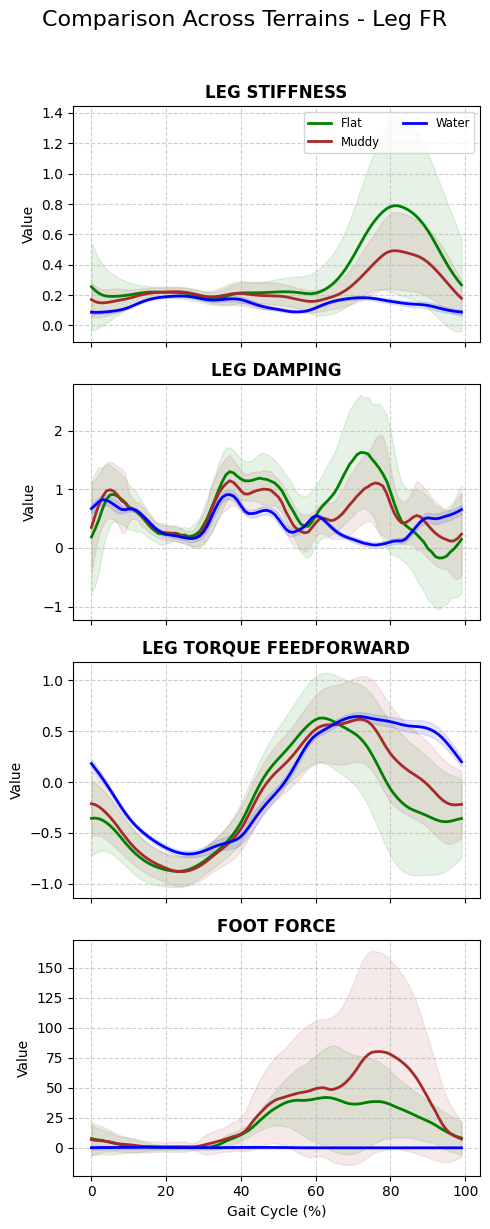

In [74]:
# List the sensors you want to visualize from the loaded file
sensors_to_plot = [
    'leg_stiffness', 
    'leg_damping', 
    'leg_torque_feedforward', 
    'foot_force'
]

# Use your previous subplot function
# Ensure name_legs is defined in your current environment
plot_all_sensors_comparison(
    dataset, 
    sensors_to_plot, 
    feature_index=0, 
    feature_name=f"Leg {name_legs[0]}"
)

# Train Process

In [75]:
import numpy as np
import random

def split_gait_dataset(dataset, train_ratio=0.8, seed=42):
    """
    Splits the gait cycle dataset into training and testing sets.
    Safely handles sensors with mismatched cycle counts.
    """
    random.seed(seed)
    train_set = {}
    test_set = {}

    for terrain in dataset.keys():
        # 1. FIND THE MINIMUM CYCLE COUNT ACROSS ALL SENSORS
        # This ensures we don't try to access an index that doesn't exist for a sensor
        sensor_counts = [len(dataset[terrain][s]) for s in dataset[terrain].keys()]
        if not sensor_counts:
            continue
            
        min_cycles = min(sensor_counts)
        
        # 2. Generate indices based on the shortest sensor stream
        indices = list(range(min_cycles))
        random.shuffle(indices)
        
        split_idx = int(min_cycles * train_ratio)
        train_indices = indices[:split_idx]
        test_indices = indices[split_idx:]
        
        train_set[terrain] = {}
        test_set[terrain] = {}

        # 3. Distribute cycles
        for sensor in dataset[terrain].keys():
            all_cycles = dataset[terrain][sensor]
            # We only take the cycles up to min_cycles to stay synchronized
            train_set[terrain][sensor] = [all_cycles[i] for i in train_indices]
            test_set[terrain][sensor] = [all_cycles[i] for i in test_indices]
            
        print(f"Terrain {terrain.upper()}: Used {min_cycles} synchronized cycles. "
              f"({len(train_indices)} train, {len(test_indices)} test)")

    return train_set, test_set

# --- Execution ---
train_data, test_data = split_gait_dataset(dataset, train_ratio=0.3)

Terrain FLAT: Used 62 synchronized cycles. (18 train, 44 test)
Terrain MUDDY: Used 59 synchronized cycles. (17 train, 42 test)
Terrain WATER: Used 53 synchronized cycles. (15 train, 38 test)


In [76]:
import numpy as np

def format_for_esn(dataset_dict, terrain_to_id_map, sensor_order):
    """
    Converts the nested dictionary into flat X and y lists for the ESN.
    
    dataset_dict: The output from your split_gait_dataset function.
    terrain_to_id_map: Dictionary mapping string terrain names to integers (e.g., {'concrete': 0, 'grass': 1}).
    sensor_order: A strict list of sensor dictionary keys to ensure columns are always in the same order.
    """
    X_formatted = []
    y_formatted = []
    
    for terrain, sensors_data in dataset_dict.items():
        if terrain not in terrain_to_id_map:
            continue # Skip terrains we aren't training on
            
        label = terrain_to_id_map[terrain]
        
        # Get the number of cycles for this terrain (they are synchronized)
        n_cycles = len(sensors_data[sensor_order[0]])
        
        for i in range(n_cycles):
            # For cycle 'i', gather data from all 16 joints (K, D, tau)
            cycle_columns = []
            for sensor_name in sensor_order:
                # Ensure it's a numpy array
                sensor_array = np.array(sensors_data[sensor_name][i])
                
                # If the sensor data is 1D (e.g., shape (90,)), reshape to (90, 1) so it stacks horizontally
                if len(sensor_array.shape) == 1:
                    sensor_array = sensor_array.reshape(-1, 1)
                    
                cycle_columns.append(sensor_array)
            
            # Stack all sensors horizontally to create the (90 timesteps x 48 features) matrix
            full_gait_matrix = np.hstack(cycle_columns)
            
            X_formatted.append(full_gait_matrix)
            y_formatted.append(label)
            
    return X_formatted, np.array(y_formatted)

In [77]:
from env_pred_5 import SignalTransformerClassifier  # Update this to wherever you saved the Signal Transformer class
import itertools
import numpy as np
import torch
import gc # Garbage collector for VRAM cleanup

# --- 1. Define your mappings to enforce consistency ---
TERRAIN_LABELS = {
    'flat': 0,
    'muddy': 1,
    'water': 2
}

# SENSOR_KEYS = list(dataset['flat'].keys()) 
# SENSOR_KEYS = ['joint_stiffness_fb', 'joint_damping_fb', 'joint_torque_ff_fb']
# SENSOR_KEYS = ['leg_stiffness', 'leg_damping', 'leg_torque_feedforward']
# SENSOR_KEYS = ['joint_torque_fb']
# SENSOR_KEYS = ['joint_torque_fb', 'foot_force']
SENSOR_KEYS = ['foot_force']

print(f"Using sensors: {SENSOR_KEYS}")

# --- 2. Split the raw dataset ---
print("Splitting dataset...")
train_data, test_data = split_gait_dataset(dataset, train_ratio=0.5, seed=42)

# --- 3. Format for the Model ---
print("\nFormatting data for Signal Transformer...")
X_train, y_train = format_for_esn(train_data, TERRAIN_LABELS, SENSOR_KEYS)
X_test, y_test = format_for_esn(test_data, TERRAIN_LABELS, SENSOR_KEYS)

print(f"Total Training Cycles: {len(X_train)}")
print(f"Total Testing Cycles: {len(X_test)}")
print(f"Input Matrix Shape: {X_train[0].shape}") 

# --- 4. Define the Signal Transformer Hyperparameter Grid ---
print("\nSetting up Signal Transformer Hyperparameter Grid Search...")

# Signal Transformer specific parameters
param_grid = {
    'embed_dim': [64, 128, 256],  # Size of the haptic signature representation [cite: 1]
    'lr': [1e-3, 5e-4],
    'batch_size': [32, 64, 128]
}

# Generate all possible combinations
keys = list(param_grid.keys())
combinations = list(itertools.product(*param_grid.values()))

print(f"Total combinations to test: {len(combinations)}\n")

# --- 5. Run the Search ---
best_accuracy = 0.0
best_params = None
# Updated filename for the Signal Transformer model and foot_force data
best_model_filename = "model_strn/env_pred_strn_best_leg_grf.pt"

for i, values in enumerate(combinations):
    # Unpack current parameters
    params = dict(zip(keys, values))
    
    print(f"\n[{i+1}/{len(combinations)}] Testing: Embed_Dim={params['embed_dim']}, "
          f"LR={params['lr']}, Batch={params['batch_size']}...")
    
    # Initialize the Signal Transformer
    # Setting epochs to 30 to balance grid search time and convergence
    model = SignalTransformerClassifier(
        embed_dim=params['embed_dim'],
        lr=params['lr'],
        batch_size=params['batch_size'],
        epochs=30
    )
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Evaluate on the test set
    correct = 0
    for j in range(len(X_test)):
        predicted_class, _ = model.predict(X_test[j])
        if predicted_class == y_test[j]:
            correct += 1
            
    accuracy = (correct / len(X_test)) * 100
    print(f"  -> Accuracy: {accuracy:.2f}%")
    
    # Check if this is the best model so far
    if accuracy > best_accuracy:
        print(f"  🌟 New Best Model! Saving to disk...")
        best_accuracy = accuracy
        best_params = params
        
        # Save directly to disk to prevent GPU memory leaks
        model.save_model(best_model_filename) 

    # --- CRITICAL: VRAM CLEANUP ---
    # Force PyTorch to clear the GPU cache before starting the next grid combination.
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# --- 6. Report the Best Model ---
print("\n" + "="*40)
print(f"🏆 BEST SIGNAL TRANSFORMER MODEL FOUND 🏆")
print(f"Accuracy: {best_accuracy:.2f}%")
print("Parameters:")
for k, v in best_params.items():
    print(f" - {k}: {v}")
print(f"Model successfully saved to: {best_model_filename}")
print("="*40 + "\n")

Using sensors: ['foot_force']
Splitting dataset...
Terrain FLAT: Used 62 synchronized cycles. (31 train, 31 test)
Terrain MUDDY: Used 59 synchronized cycles. (29 train, 30 test)
Terrain WATER: Used 53 synchronized cycles. (26 train, 27 test)

Formatting data for Signal Transformer...
Total Training Cycles: 86
Total Testing Cycles: 88
Input Matrix Shape: (100, 4)

Setting up Signal Transformer Hyperparameter Grid Search...
Total combinations to test: 18


[1/18] Testing: Embed_Dim=64, LR=0.001, Batch=32...
Training Signal Transformer on 86 gait cycles using cuda...
Epoch [1/30] | Loss: 1.0072 | Accuracy: 54.65%
Epoch [10/30] | Loss: 0.5936 | Accuracy: 79.07%
Epoch [20/30] | Loss: 0.4874 | Accuracy: 75.58%
Epoch [30/30] | Loss: 0.3946 | Accuracy: 81.40%
Signal Transformer Training complete.
  -> Accuracy: 71.59%
  🌟 New Best Model! Saving to disk...
Signal Transformer parameters saved to model_strn/env_pred_strn_best_leg_grf.pt

[2/18] Testing: Embed_Dim=64, LR=0.001, Batch=64...
Trainin

Booting up Signal Transformer Classifier...

[SUCCESS] Signal Transformer Model loaded from: 'model_strn/env_pred_strn_best_leg_grf.pt'
----------------------------------------
💡 Hyperparameters:
   • Attention Heads: 2
   • Embedding Size:  256
   • Target Classes:  3
----------------------------------------


Evaluating on unseen Test Set...
Test Accuracy: 79.55%


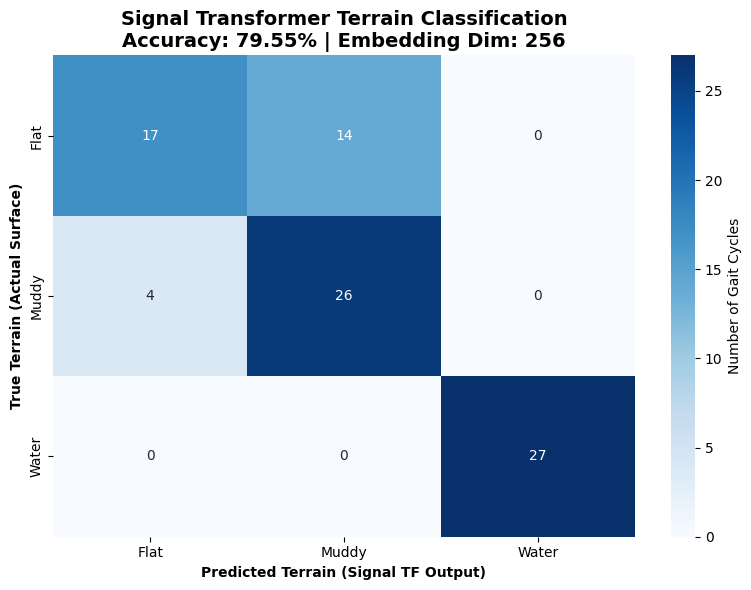

In [78]:
import numpy as np
from env_pred_5 import SignalTransformerClassifier  # Ensure this points to where you saved the Signal Transformer class!
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ==========================================
# 1. LOAD THE MODEL
# ==========================================
print("Booting up Signal Transformer Classifier...")

# Initialize an empty model (initial parameters don't matter, they get overwritten)
model = SignalTransformerClassifier()

# Load the weights from the file generated by your Grid Search
# Update the path to match the one you just saved!
MODEL_FILENAME = best_model_filename
model.load_model(MODEL_FILENAME)

# ==========================================
# 2. DEFINE YOUR MAPPINGS
# ==========================================
# Create a mapping to turn the integer back into a readable string
ID_TO_TERRAIN = {
    0: 'Flat',
    1: 'Muddy',
    2: 'Water'
}

# ==========================================
# 3. EVALUATION & CONFUSION MATRIX
# ==========================================

print("\nEvaluating on unseen Test Set...")
y_pred = []

# Collect all predictions (Assuming X_test and y_test exist in your memory)
for i in range(len(X_test)):
    predicted_class, confidence = model.predict(X_test[i])
    y_pred.append(predicted_class)

# Convert to numpy array for fast comparison
y_pred = np.array(y_pred)

# Calculate Accuracy
correct = np.sum(y_pred == y_test)
accuracy = (correct / len(X_test)) * 100
print(f"Test Accuracy: {accuracy:.2f}%")

# --- Generate Confusion Matrix Heatmap ---
cm = confusion_matrix(y_test, y_pred)

# Extract terrain names in the correct ID order (0, 1, 2) directly from ID_TO_TERRAIN
terrain_names = [ID_TO_TERRAIN[i] for i in sorted(ID_TO_TERRAIN.keys())]

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=terrain_names, 
            yticklabels=terrain_names,
            cbar_kws={'label': 'Number of Gait Cycles'})

# UPDATED: Replaced TCN attributes with Signal Transformer attributes for the title
plt.title(f'Signal Transformer Terrain Classification\nAccuracy: {accuracy:.2f}% | Embedding Dim: {model.embed_dim}', fontsize=14, fontweight='bold')
plt.ylabel('True Terrain (Actual Surface)', fontweight='bold')
plt.xlabel('Predicted Terrain (Signal TF Output)', fontweight='bold')
plt.tight_layout()
plt.show()